# 1 · Improved Deep SVDD — Bug Fixes + CLAHE + Early Stopping

This notebook tries to fix critical bugs from `DeepSVDDNorm` that caused AUROC to hover near random (~0.5–0.6) and early collapse

- Removed F.normalize(z, p=2, dim=1) in forward
- removed all bias=true in nn.Linear layers Projection Head
- make sure to set use_bn= False as BatchNorm would shift embeddings to zero-mean, encouraging collapse

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from src.models import DeepSVDD, DeepSVDDWithSE
from src.dataset import build_image_index, CrackDataset, save_splits, load_splits
from src.train_utils import (
    train_svdd_epoch, eval_scores,
    calibrate_threshold, compute_metrics, print_metrics,
)
from src.viz_utils import (
    plot_score_histogram, plot_roc_curve, plot_pr_curve,
    plot_confusion_matrix, plot_tsne, plot_bar_ablation,
)


DATASET_DIR   = 'SDNET2018'
SPLITS_DIR    = 'splits'
CKPT_DIR      = 'checkpoints'
RESULTS_DIR   = 'results'
RANDOM_STATE  = 42
BATCH_SIZE    = 64
NUM_WORKERS   = 0
PREPROCESSING = 'none' 

# Model
OUT_DIM      = 128   
WEIGHT_DECAY = 1e-4  
LR           = 1e-4  

# Training
MAX_EPOCHS   = 50    # upper bound 
PATIENCE     = 7    

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {DEVICE}')
print(f'Preprocessing: {PREPROCESSING}')
print(f'out_dim      : {OUT_DIM}')
print(f'weight_decay : {WEIGHT_DECAY}')
print(f'patience     : {PATIENCE} epochs')

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device       : cuda
Preprocessing: none
out_dim      : 128
weight_decay : 0.0001
patience     : 7 epochs


In [2]:
splits_exist = all(
    os.path.exists(os.path.join(SPLITS_DIR, f'patch_index_{s}.pkl'))
    for s in ('train', 'val', 'test')
)

if splits_exist:
    train_records, val_records, test_records = load_splits(SPLITS_DIR)
    print('Loaded existing splits.')
else:
    print('Splits not found — regenerating...')
    all_records = build_image_index(DATASET_DIR)
    labels_all  = np.array([r['label'] for r in all_records])
    train_records, temp_records = train_test_split(
        all_records, test_size=0.30, stratify=labels_all, random_state=RANDOM_STATE)
    temp_labels = np.array([r['label'] for r in temp_records])
    val_records, test_records = train_test_split(
        temp_records, test_size=0.50, stratify=temp_labels, random_state=RANDOM_STATE)
    save_splits(train_records, val_records, test_records, SPLITS_DIR)


train_normal_ds = CrackDataset(train_records, preprocessing=PREPROCESSING,
                                augment=True, normal_only=True)
val_ds          = CrackDataset(val_records,   preprocessing=PREPROCESSING)
test_ds         = CrackDataset(test_records,  preprocessing=PREPROCESSING)

train_loader = DataLoader(train_normal_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,          batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,         batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f'Train (normal only): {len(train_normal_ds):,}')
print(f'Val               : {len(val_ds):,}')
print(f'Test              : {len(test_ds):,}')

Loaded existing splits.
Train (normal only): 15,207
Val               : 3,650
Test              : 3,651


In [3]:
class EarlyStopping:
    
    def __init__(self, patience: int, ckpt_path: str, min_delta: float = 1e-4):
        self.patience   = patience
        self.ckpt_path  = ckpt_path
        self.min_delta  = min_delta
        self.best_auroc = -1.0
        self.counter    = 0
        self.best_epoch = 0

    def step(self, auroc: float, model: torch.nn.Module,
             extra: dict = None) -> bool:
        
        if auroc > self.best_auroc + self.min_delta:
            self.best_auroc = auroc
            self.counter    = 0
            self.best_epoch = len(extra.get('val_aurocs', [])) if extra else 0
            payload = {'model_state': model.state_dict()}
            if extra:
                payload.update(extra)
            torch.save(payload, self.ckpt_path)
        else:
            self.counter += 1

        return self.counter >= self.patience

    def summary(self) -> str:
        return (f'Best val AUROC: {self.best_auroc:.4f} '
                f'(epoch {self.best_epoch})  '
                f'stopped after {self.counter} epochs without improvement')

print('EarlyStopping helper defined.')

EarlyStopping helper defined.


## Train  DeepSVDD

**Architecture choices:**
- `freeze_up_to='layer2'`
- `hidden_dims=[256]`
- `out_dim=128` 
- `use_bn=False`

**All `nn.Linear` layers have `bias=False`** (fix in `src/models.py`)  
**No `F.normalize` in forward** (fix in `src/models.py`)

We use ImageNet-pretrained ResNet-18 weights and freeze the encoder up to layer2 (conv1, bn1, layer1, and layer2). We also keep all encoder BatchNorm2d layers frozen in evaluation mode, including their running statistics and affine parameters (gamma and beta). This is done because Batch Normalization can undermine Deep SVDD by introducing shift and scale flexibility that makes hypersphere collapse easier, whereas freezing BN helps preserve stable pretrained features during one-class optimisation.

In [4]:
model_svdd = DeepSVDD(
    freeze_up_to='layer2',
    hidden_dims=[256],
    out_dim=OUT_DIM,
    use_bn=False,
    dropout=0.0,
    pretrained=True,
).to(DEVICE)

model_svdd.init_centre(train_loader, DEVICE)

# Lock BN running stats AND learnable γ/β — Ruff et al. (2018) warns that
# BN encourages hypersphere collapse (zero-mean shift). m.eval() locks running
# stats; requires_grad_(False) prevents β (per-channel bias) from being exploited.
for m in model_svdd.encoder.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()
        m.weight.requires_grad_(False)   # freeze γ
        m.bias.requires_grad_(False)     # freeze β (acts as bias — collapse risk)

optimizer_svdd = optim.Adam(
    filter(lambda p: p.requires_grad, model_svdd.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

es_svdd = EarlyStopping(
    patience  = PATIENCE,
    ckpt_path = os.path.join(CKPT_DIR, 'improved_svdd_best.pt'),
)

train_losses_svdd = []
val_aurocs_svdd   = []

print(f'Training DeepSVDD (max {MAX_EPOCHS} epochs, patience={PATIENCE})...')
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_svdd_epoch(model_svdd, train_loader, optimizer_svdd, DEVICE)
    train_losses_svdd.append(tr_loss)

    val_scores, val_labels_es = eval_scores(model_svdd, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_labels_es, val_scores))
    val_aurocs_svdd.append(val_auroc)

    marker = ' ★' if val_auroc >= es_svdd.best_auroc else ''
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'  Epoch {epoch:3d}  loss={tr_loss:.5f}  val_AUROC={val_auroc:.4f}{marker}')

    stop = es_svdd.step(val_auroc, model_svdd,
                        extra={'train_losses': train_losses_svdd,
                               'val_aurocs':   val_aurocs_svdd})
    if stop:
        print(f'  Early stop at epoch {epoch}.')
        break

print(es_svdd.summary())

init_centre: 100%|██████████| 238/238 [00:53<00:00,  4.47it/s]


  Centre initialised — mean norm: 2.4356
Training DeepSVDD (max 50 epochs, patience=7)...
  Epoch   1  loss=0.13373  val_AUROC=0.6642 ★
  Epoch   5  loss=0.00112  val_AUROC=0.6650 ★
  Epoch   7  loss=0.00082  val_AUROC=0.6703 ★
  Epoch  10  loss=0.00047  val_AUROC=0.6277
  Early stop at epoch 14.
Best val AUROC: 0.6703 (epoch 7)  stopped after 7 epochs without improvement


## Train DeepSVDDWithSE

Tried Squeeze-and-Extraction(SE) channel attention to force diverse per-channel feature weighting, preventing all embeddings collapsing to the same direction.

This might help to re-weight each feature channel by its global importance, hoping that the irrelevent background texture would be suppressed and amplifying the crack.

Without attention, all 512 ResNet channels contribute equally to the final embedding. Normal concrete images and cracked images may differ in only a small subset of channels (e.g. edge discontinuity detectors). SE attention might allow the the model to concentrate the hypersphere boundary around those discriminative channels

`freeze_up_to='layer1'` — less frozen than plain SVDD because the SE block needs the encoder to remain somewhat plastic to learn channel weights.

In [5]:
model_se = DeepSVDDWithSE(
    freeze_up_to='layer1',
    hidden_dims=[256, 128],
    out_dim=OUT_DIM,
    dropout=0.0,
    pretrained=True,
    se_reduction=16,
).to(DEVICE)

model_se.init_centre(train_loader, DEVICE)

# Lock BN running stats AND learnable γ/β
for m in model_se.encoder.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()
        m.weight.requires_grad_(False)   # freeze γ
        m.bias.requires_grad_(False)     # freeze β (acts as bias — collapse risk)

optimizer_se = optim.Adam(
    filter(lambda p: p.requires_grad, model_se.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

es_se = EarlyStopping(
    patience  = PATIENCE,
    ckpt_path = os.path.join(CKPT_DIR, 'improved_svdd_se_best.pt'),
)

train_losses_se = []
val_aurocs_se   = []

print(f'Training DeepSVDDWithSE (max {MAX_EPOCHS} epochs, patience={PATIENCE})...')
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_svdd_epoch(model_se, train_loader, optimizer_se, DEVICE)
    train_losses_se.append(tr_loss)

    val_scores, val_labels_es = eval_scores(model_se, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_labels_es, val_scores))
    val_aurocs_se.append(val_auroc)

    marker = ' ★' if val_auroc >= es_se.best_auroc else ''
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'  Epoch {epoch:3d}  loss={tr_loss:.5f}  val_AUROC={val_auroc:.4f}{marker}')

    stop = es_se.step(val_auroc, model_se,
                      extra={'train_losses': train_losses_se,
                             'val_aurocs':   val_aurocs_se})
    if stop:
        print(f'  Early stop at epoch {epoch}.')
        break

print(es_se.summary())

init_centre: 100%|██████████| 238/238 [00:50<00:00,  4.70it/s]


  Centre initialised — mean norm: 1.1315
Training DeepSVDDWithSE (max 50 epochs, patience=7)...
  Epoch   1  loss=0.04007  val_AUROC=0.6094 ★
  Epoch   2  loss=0.00024  val_AUROC=0.6431 ★
  Epoch   5  loss=0.00010  val_AUROC=0.5316
  Early stop at epoch 9.
Best val AUROC: 0.6431 (epoch 2)  stopped after 7 epochs without improvement


## AdaptiveMaxPool vs AvgPool

For this dataset where the crack covers ~3% of pixels, max-pooling over the 8×8 spatial grid might preserves the peak activation from crack locations rather than diluting it with background.

Pooling layer: AdaptiveMaxPool2d(output_size=(1, 1))


init_centre: 100%|██████████| 238/238 [00:50<00:00,  4.68it/s]


  Centre initialised — mean norm: 7.4584
Training DeepSVDD+MaxPool (max 50 epochs, patience=7)...
  Epoch   1  loss=2.686934  val_AUROC=0.5891 *
  Epoch   2  loss=0.108679  val_AUROC=0.6058 *
  Epoch   3  loss=0.051744  val_AUROC=0.6261 *
  Epoch   4  loss=0.031121  val_AUROC=0.6323 *
  Epoch   5  loss=0.021820  val_AUROC=0.6337 *
  Epoch   8  loss=0.011524  val_AUROC=0.6350 *
  Epoch  10  loss=0.007877  val_AUROC=0.6218
  Epoch  11  loss=0.007295  val_AUROC=0.6382 *
  Epoch  12  loss=0.007039  val_AUROC=0.6399 *
  Epoch  15  loss=0.004526  val_AUROC=0.6432 *
  Epoch  20  loss=0.003197  val_AUROC=0.6218
  Early stop at epoch 22.
Best val AUROC: 0.6432 (epoch 15)  stopped after 7 epochs without improvement


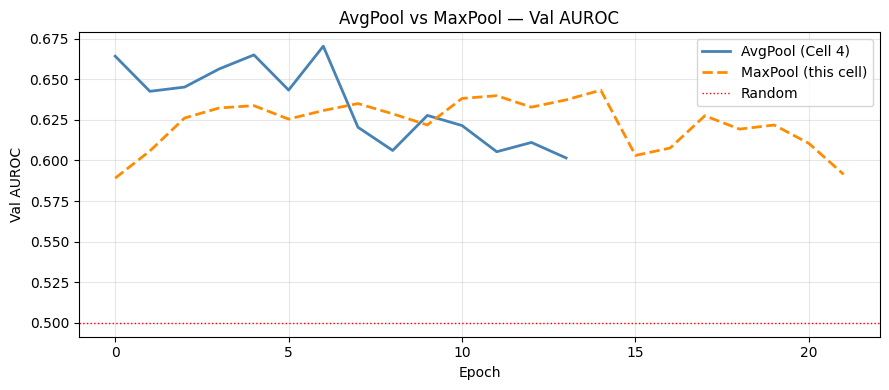

AvgPool best val AUROC : 0.6703
MaxPool best val AUROC : 0.6432
Delta (max - avg)      : -0.0271


In [6]:
import torch.nn as nn

model_svdd_mp = DeepSVDD(
    freeze_up_to='layer2',
    hidden_dims=[256],
    out_dim=OUT_DIM,
    use_bn=False,
    pretrained=True,
).to(DEVICE)


model_svdd_mp.encoder[-1] = nn.AdaptiveMaxPool2d((1, 1))
print('Pooling layer:', model_svdd_mp.encoder[-1])

model_svdd_mp.init_centre(train_loader, DEVICE)

optimizer_mp = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svdd_mp.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

es_mp = EarlyStopping(
    patience=PATIENCE,
    ckpt_path=os.path.join(CKPT_DIR, 'svdd_maxpool_best.pt'),
)

train_losses_mp = []
val_aurocs_mp   = []

print(f'Training DeepSVDD+MaxPool (max {MAX_EPOCHS} epochs, patience={PATIENCE})...')
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_svdd_epoch(model_svdd_mp, train_loader, optimizer_mp, DEVICE)
    train_losses_mp.append(tr_loss)

    val_scores_mp, val_labels_mp = eval_scores(model_svdd_mp, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_labels_mp, val_scores_mp))
    val_aurocs_mp.append(val_auroc)

    marker = ' *' if val_auroc >= es_mp.best_auroc else ''
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'  Epoch {epoch:3d}  loss={tr_loss:.6f}  val_AUROC={val_auroc:.4f}{marker}')

    stop = es_mp.step(val_auroc, model_svdd_mp,
                      extra={'train_losses': train_losses_mp,
                             'val_aurocs':   val_aurocs_mp})
    if stop:
        print(f'  Early stop at epoch {epoch}.')
        break

print(es_mp.summary())


fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(val_aurocs_svdd, label='AvgPool (Cell 4)', color='steelblue', lw=2)
ax.plot(val_aurocs_mp,   label='MaxPool (this cell)', color='darkorange', lw=2, linestyle='--')
ax.axhline(0.5, color='red', linestyle=':', lw=1, label='Random')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUROC')
ax.set_title('AvgPool vs MaxPool — Val AUROC')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'svdd_pool_ablation.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'AvgPool best val AUROC : {max(val_aurocs_svdd):.4f}')
print(f'MaxPool best val AUROC : {max(val_aurocs_mp):.4f}')
print(f'Delta (max - avg)      : {max(val_aurocs_mp) - max(val_aurocs_svdd):+.4f}')

## Training Curves

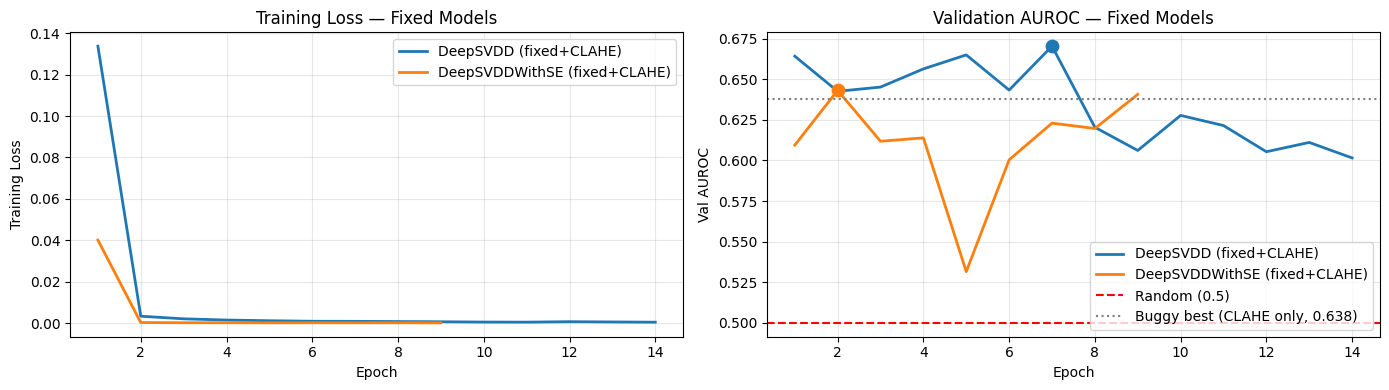

Best val AUROC — DeepSVDD      : 0.6703 (epoch 7)
Best val AUROC — DeepSVDDWithSE: 0.6431 (epoch 2)


In [7]:
epochs_svdd = range(1, len(train_losses_svdd) + 1)
epochs_se   = range(1, len(train_losses_se)   + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(epochs_svdd, train_losses_svdd, label='DeepSVDD (fixed+CLAHE)', lw=2)
axes[0].plot(epochs_se,   train_losses_se,   label='DeepSVDDWithSE (fixed+CLAHE)', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss — Fixed Models')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Val AUROC
axes[1].plot(epochs_svdd, val_aurocs_svdd, label='DeepSVDD (fixed+CLAHE)', lw=2)
axes[1].plot(epochs_se,   val_aurocs_se,   label='DeepSVDDWithSE (fixed+CLAHE)', lw=2)
axes[1].axhline(0.5,  color='red',    linestyle='--', lw=1.5, label='Random (0.5)')
axes[1].axhline(0.638, color='grey',  linestyle=':',  lw=1.5, label='Buggy best (CLAHE only, 0.638)')
# Mark best epochs
best_e_svdd = int(np.argmax(val_aurocs_svdd))
best_e_se   = int(np.argmax(val_aurocs_se))
axes[1].scatter(best_e_svdd + 1, val_aurocs_svdd[best_e_svdd], s=80, zorder=5)
axes[1].scatter(best_e_se   + 1, val_aurocs_se[best_e_se],     s=80, zorder=5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val AUROC')
axes[1].set_title('Validation AUROC — Fixed Models')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'Best val AUROC — DeepSVDD      : {max(val_aurocs_svdd):.4f} (epoch {best_e_svdd+1})')
print(f'Best val AUROC — DeepSVDDWithSE: {max(val_aurocs_se):.4f} (epoch {best_e_se+1})')

## Evaluate on Test Set

In [8]:
#load
ckpt_svdd = torch.load(os.path.join(CKPT_DIR, 'improved_svdd_best.pt'),
                        map_location=DEVICE, weights_only=True)
model_svdd.load_state_dict(ckpt_svdd['model_state'])

ckpt_se = torch.load(os.path.join(CKPT_DIR, 'improved_svdd_se_best.pt'),
                      map_location=DEVICE, weights_only=True)
model_se.load_state_dict(ckpt_se['model_state'])

# calibrate threshold on val set using best weights
val_scores_svdd, val_labels_cal = eval_scores(model_svdd, val_loader, DEVICE)
val_scores_se,   _              = eval_scores(model_se,   val_loader, DEVICE)

tau_svdd, _ = calibrate_threshold(val_scores_svdd, val_labels_cal)
tau_se,   _ = calibrate_threshold(val_scores_se,   val_labels_cal)

# test scores
test_scores_svdd, test_labels = eval_scores(model_svdd, test_loader, DEVICE)
test_scores_se,   _           = eval_scores(model_se,   test_loader, DEVICE)


metrics_svdd = compute_metrics(test_scores_svdd, test_labels, tau_svdd)
metrics_se   = compute_metrics(test_scores_se,   test_labels, tau_se)

print('DeepSVDD')
print_metrics(metrics_svdd, 'DeepSVDD')
print()
print('DeepSVDDWithSE')
print_metrics(metrics_se, 'DeepSVDDWithSE')

# Save results
import pickle
with open(os.path.join(RESULTS_DIR, 'results_improved_svdd.pkl'), 'wb') as f:
    pickle.dump({
        'svdd': {'scores': test_scores_svdd, 'labels': test_labels,
                 'tau': tau_svdd, **{k: v for k, v in metrics_svdd.items() if k != 'preds'}},
        'se':   {'scores': test_scores_se,   'labels': test_labels,
                 'tau': tau_se,   **{k: v for k, v in metrics_se.items()   if k != 'preds'}},
    }, f)
print('Results saved.')

DeepSVDD
[DeepSVDD] AUROC: 0.6413  AUPRC: 0.1555  F1: 0.2340
  Confusion matrix:
    TN=  2534  FP=   726
    FN=   243  TP=   148

DeepSVDDWithSE
[DeepSVDDWithSE] AUROC: 0.6153  AUPRC: 0.1525  F1: 0.2393
  Confusion matrix:
    TN=  2540  FP=   720
    FN=   240  TP=   151
Results saved.


## Score Distribution Histograms

Normal scores (blue) should peak near small values; anomaly scores (orange) shifted right. The threshold line should separate them. If both distributions completely overlap → model collapsing.

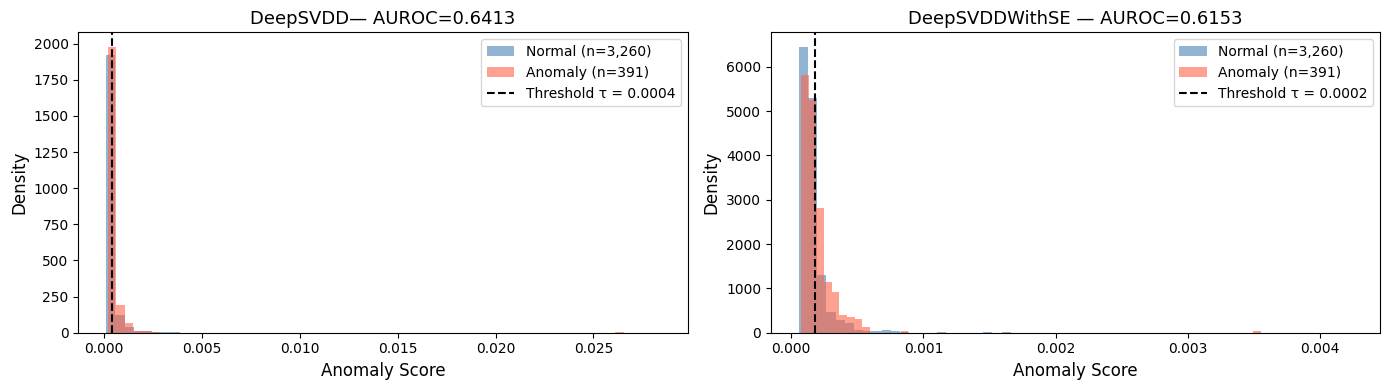

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_score_histogram(test_scores_svdd, test_labels, threshold=tau_svdd,
                     title=f'DeepSVDD— AUROC={metrics_svdd["auroc"]:.4f}',
                     ax=axes[0])
plot_score_histogram(test_scores_se,   test_labels, threshold=tau_se,
                     title=f'DeepSVDDWithSE — AUROC={metrics_se["auroc"]:.4f}',
                     ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'score_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()

Above we still do see signs of model collapse

## ROC Curves & Confusion Matrices

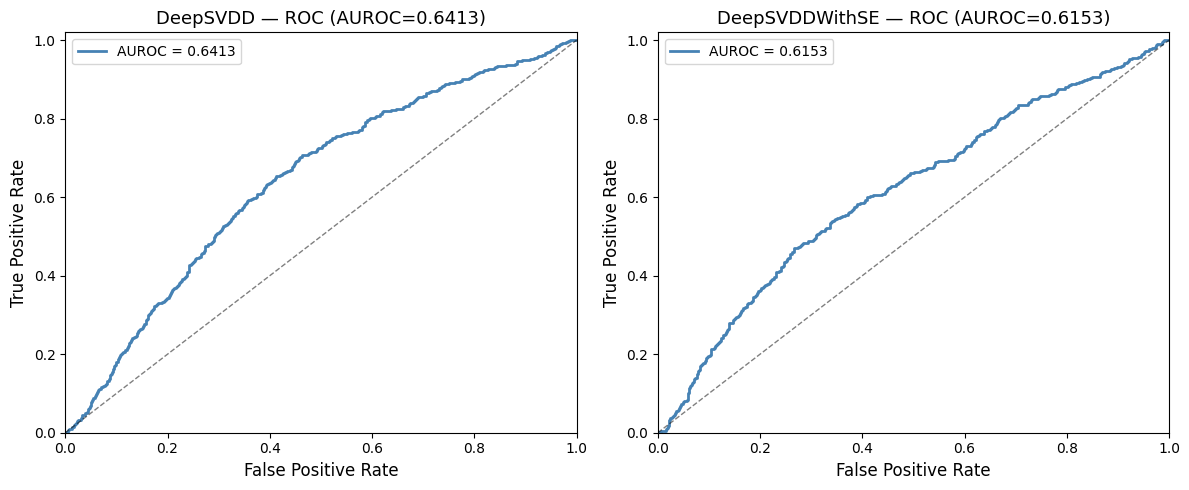

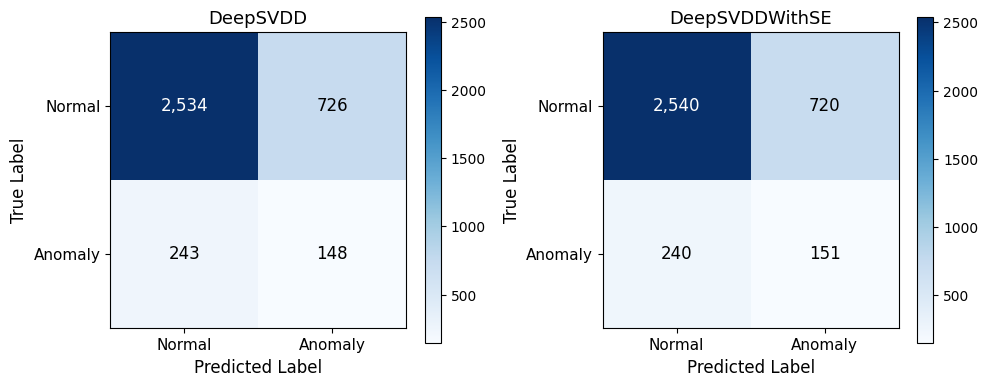

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_roc_curve(test_scores_svdd, test_labels,
               auroc=metrics_svdd["auroc"],
               title=f'DeepSVDD — ROC (AUROC={metrics_svdd["auroc"]:.4f})',
               ax=axes[0])
plot_roc_curve(test_scores_se, test_labels,
               auroc=metrics_se["auroc"],
               title=f'DeepSVDDWithSE — ROC (AUROC={metrics_se["auroc"]:.4f})',
               ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(metrics_svdd['cm'],
                      title='DeepSVDD', ax=axes[0])
plot_confusion_matrix(metrics_se['cm'],
                      title='DeepSVDDWithSE', ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()

## Training with AE Warm-Start Ablation


The original Deep SVDD paper (Ruff et al., 2018) recommends pretraining the encoder as an autoencoder before SVDD training. The reconstruction loss forces the network to learn meaningful features before the one-class loss takes over. The paper did the training from scratch but we will started with ImageNet-pretrained ResNet-18.


### Approach

The encoder (ae_host) starts from ImageNet-pretrained ResNet-18 weights (downloaded via pretrained=True). These weights already know how to detect edges, textures, shapes from 1.2M ImageNet images.

The AE pretraining then fine-tunes that encoder for 5 epochs on the crack images using reconstruction loss so it adapts the ImageNet features to concrete texture specifically.

```
ResNet-18 encoder → avgpool → (B, 512, 1, 1)
                           ↓ AE pretraining only
              Decoder: ConvTranspose2d x5 → (B, 3, 256, 256)
```

In [11]:
class ResNetDecoder(nn.Module):

    def __init__(self):
        super().__init__()
        self.up = nn.Sequential(
            # (B, 512, 1, 1) -> (B, 256, 2, 2)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            # -> (B, 128, 4, 4)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            # -> (B, 64, 8, 8)
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            # -> (B, 32, 32, 32)  stride=4 jumps 8->32
            nn.ConvTranspose2d(64,  32,  kernel_size=8, stride=4, padding=2),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            # -> (B, 3, 256, 256)  stride=8 jumps 32->256
            nn.ConvTranspose2d(32,  3,   kernel_size=16, stride=8, padding=4),
            nn.Sigmoid(),
        )

    def forward(self, z):
        # z: (B, 512) — reshape to (B, 512, 1, 1) before upsampling
        return self.up(z.view(z.size(0), 512, 1, 1))



_tmp_model = DeepSVDD(pretrained=True).to(DEVICE)
_tmp_dec   = ResNetDecoder().to(DEVICE)
_x_tmp     = torch.randn(2, 3, 256, 256).to(DEVICE)
_z_tmp     = _tmp_model.encoder(_x_tmp).flatten(1)
_r_tmp     = _tmp_dec(_z_tmp)
print(f"Encoder output : {_z_tmp.shape}")
print(f"Decoder output : {_r_tmp.shape}  (should be torch.Size([2, 3, 256, 256]))")
del _tmp_model, _tmp_dec, _x_tmp, _z_tmp, _r_tmp
torch.cuda.empty_cache()

Encoder output : torch.Size([2, 512])
Decoder output : torch.Size([2, 3, 256, 256])  (should be torch.Size([2, 3, 256, 256]))


In [12]:
AE_EPOCHS = 5
# Use plain DeepSVDD (no SE) as AE host — SE is a discrimination mechanism,
# not a reconstruction one. Training SE under reconstruction loss would set its
# weights to whatever helps MSE, not what helps anomaly detection.
# Encoder weights are transferred to DeepSVDDWithSE in the next cell.
ae_host = DeepSVDD(
    freeze_up_to=None,
    hidden_dims=[256, 128],
    out_dim=OUT_DIM,
    dropout=0.0,
    pretrained=True,
).to(DEVICE)

ae_decoder   = ResNetDecoder().to(DEVICE)
ae_params    = list(ae_host.encoder.parameters()) + list(ae_decoder.parameters())
ae_optimizer = optim.Adam(ae_params, lr=1e-4, weight_decay=1e-4)
ae_criterion = nn.MSELoss()

ae_losses = []
print(f"AE pretraining — {AE_EPOCHS} epochs on normal images...")
for epoch in range(1, AE_EPOCHS + 1):
    ae_host.train()
    ae_decoder.train()
    total = 0.0
    for x, _ in train_loader:
        x     = x.to(DEVICE)
        z     = ae_host.encoder(x).flatten(1)   # (B, 512)
        recon = ae_decoder(z)
        loss  = ae_criterion(recon, x)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total += loss.item()
    avg = total / len(train_loader)
    ae_losses.append(avg)
    print(f"  AE Epoch {epoch}/{AE_EPOCHS}  recon_loss={avg:.5f}")

del ae_decoder
torch.cuda.empty_cache()
print("Decoder discarded. Encoder weights ready for warm-start.")

AE pretraining — 5 epochs on normal images...
  AE Epoch 1/5  recon_loss=0.58691
  AE Epoch 2/5  recon_loss=0.46688
  AE Epoch 3/5  recon_loss=0.44266
  AE Epoch 4/5  recon_loss=0.43594
  AE Epoch 5/5  recon_loss=0.43136
Decoder discarded. Encoder weights ready for warm-start.


In [13]:
# build the warm-started SVDD model and copy pretrained encoder weights
model_se_warm = DeepSVDDWithSE(
    freeze_up_to="layer1",
    hidden_dims=[256, 128],
    out_dim=OUT_DIM,
    dropout=0.0,
    pretrained=False,   # weights loaded manually below
    se_reduction=16,
).to(DEVICE)

# Transfer AE-pretrained encoder weights
model_se_warm.encoder.load_state_dict(ae_host.encoder.state_dict())
del ae_host
torch.cuda.empty_cache()
print("AE encoder weights transferred to model_se_warm.")

# Reapply layer1 freeze (same as cold-start SE config)
import torchvision.models as _tvm
_bb = _tvm.resnet18(weights=None)
model_se_warm._freeze_encoder(_bb, "layer1")
del _bb

model_se_warm.init_centre(train_loader, DEVICE)

# Lock BN running stats AND learnable γ/β — preserves AE-pretraining statistics
for m in model_se_warm.encoder.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()
        m.weight.requires_grad_(False)   # freeze γ
        m.bias.requires_grad_(False)     # freeze β (acts as bias — collapse risk)

optimizer_se_warm = optim.Adam(
    filter(lambda p: p.requires_grad, model_se_warm.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

es_se_warm = EarlyStopping(
    patience  = PATIENCE,
    ckpt_path = os.path.join(CKPT_DIR, "improved_svdd_se_warm_best.pt"),
)

train_losses_se_warm = []
val_aurocs_se_warm   = []

print(f"Training AE-warm-started SE (max {MAX_EPOCHS} epochs, patience={PATIENCE})...")
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_svdd_epoch(model_se_warm, train_loader, optimizer_se_warm, DEVICE)
    train_losses_se_warm.append(tr_loss)

    val_scores_w, val_labels_w = eval_scores(model_se_warm, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_labels_w, val_scores_w))
    val_aurocs_se_warm.append(val_auroc)

    marker = " *" if val_auroc >= es_se_warm.best_auroc else ""
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"  Epoch {epoch:3d}  loss={tr_loss:.5f}  val_AUROC={val_auroc:.4f}{marker}")

    stop = es_se_warm.step(val_auroc, model_se_warm,
                           extra={"train_losses": train_losses_se_warm,
                                  "val_aurocs":   val_aurocs_se_warm})
    if stop:
        print(f"  Early stop at epoch {epoch}.")
        break

print(es_se_warm.summary())

AE encoder weights transferred to model_se_warm.


init_centre: 100%|██████████| 238/238 [00:51<00:00,  4.65it/s]


  Centre initialised — mean norm: 1.1314
Training AE-warm-started SE (max 50 epochs, patience=7)...
  Epoch   1  loss=0.02785  val_AUROC=0.5696 *
  Epoch   5  loss=0.00019  val_AUROC=0.5091
  Early stop at epoch 8.
Best val AUROC: 0.5696 (epoch 1)  stopped after 7 epochs without improvement


In [15]:
# Re-run AE pretraining for plain DeepSVDD warm-start
# (ae_host was deleted in cell 23 — need a fresh one)
ae_host2 = DeepSVDD(
    freeze_up_to=None,
    hidden_dims=[256, 128],
    out_dim=OUT_DIM,
    dropout=0.0,
    pretrained=True,
).to(DEVICE)

ae_decoder2   = ResNetDecoder().to(DEVICE)
ae_params2    = list(ae_host2.encoder.parameters()) + list(ae_decoder2.parameters())
ae_optimizer2 = optim.Adam(ae_params2, lr=1e-4, weight_decay=1e-4)
ae_criterion2 = nn.MSELoss()

print(f"AE pretraining for DeepSVDD warm-start — {AE_EPOCHS} epochs...")
for epoch in range(1, AE_EPOCHS + 1):
    ae_host2.train()
    ae_decoder2.train()
    total = 0.0
    for x, _ in train_loader:
        x     = x.to(DEVICE)
        z     = ae_host2.encoder(x).flatten(1)
        recon = ae_decoder2(z)
        loss  = ae_criterion2(recon, x)
        ae_optimizer2.zero_grad()
        loss.backward()
        ae_optimizer2.step()
        total += loss.item()
    avg = total / len(train_loader)
    print(f"  AE Epoch {epoch}/{AE_EPOCHS}  recon_loss={avg:.5f}")

del ae_decoder2
torch.cuda.empty_cache()
print("Decoder discarded.")

# Build plain DeepSVDD warm-start model
model_svdd_warm = DeepSVDD(
    freeze_up_to='layer2',
    hidden_dims=[256],
    out_dim=OUT_DIM,
    use_bn=False,
    dropout=0.0,
    pretrained=False,
).to(DEVICE)

# Transfer AE-pretrained encoder weights
model_svdd_warm.encoder.load_state_dict(ae_host2.encoder.state_dict())
del ae_host2
torch.cuda.empty_cache()
print("AE encoder weights transferred to model_svdd_warm.")

model_svdd_warm.init_centre(train_loader, DEVICE)

# Lock BN γ/β and running stats
for m in model_svdd_warm.encoder.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()
        m.weight.requires_grad_(False)
        m.bias.requires_grad_(False)

optimizer_svdd_warm = optim.Adam(
    filter(lambda p: p.requires_grad, model_svdd_warm.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

es_svdd_warm = EarlyStopping(
    patience  = PATIENCE,
    ckpt_path = os.path.join(CKPT_DIR, 'improved_svdd_warm_best.pt'),
)

train_losses_svdd_warm = []
val_aurocs_svdd_warm   = []

print(f"Training DeepSVDD AE warm-start (max {MAX_EPOCHS} epochs, patience={PATIENCE})...")
for epoch in range(1, MAX_EPOCHS + 1):
    model_svdd_warm.train()
    for m in model_svdd_warm.encoder.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()
            m.weight.requires_grad_(False)
            m.bias.requires_grad_(False)

    tr_loss = train_svdd_epoch(model_svdd_warm, train_loader, optimizer_svdd_warm, DEVICE)
    train_losses_svdd_warm.append(tr_loss)

    val_scores_sw, val_labels_sw = eval_scores(model_svdd_warm, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_labels_sw, val_scores_sw))
    val_aurocs_svdd_warm.append(val_auroc)

    marker = ' ★' if val_auroc >= es_svdd_warm.best_auroc else ''
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'  Epoch {epoch:3d}  loss={tr_loss:.5f}  val_AUROC={val_auroc:.4f}{marker}')

    stop = es_svdd_warm.step(val_auroc, model_svdd_warm,
                             extra={'train_losses': train_losses_svdd_warm,
                                    'val_aurocs':   val_aurocs_svdd_warm})
    if stop:
        print(f'  Early stop at epoch {epoch}.')
        break

print(es_svdd_warm.summary())

AE pretraining for DeepSVDD warm-start — 5 epochs...
  AE Epoch 1/5  recon_loss=0.59493
  AE Epoch 2/5  recon_loss=0.49138
  AE Epoch 3/5  recon_loss=0.46162
  AE Epoch 4/5  recon_loss=0.44741
  AE Epoch 5/5  recon_loss=0.43753
Decoder discarded.
AE encoder weights transferred to model_svdd_warm.


init_centre: 100%|██████████| 238/238 [00:51<00:00,  4.66it/s]


  Centre initialised — mean norm: 1.9947
Training DeepSVDD AE warm-start (max 50 epochs, patience=7)...
  Epoch   1  loss=0.02962  val_AUROC=0.6382 ★
  Epoch   2  loss=0.00006  val_AUROC=0.6540 ★
  Epoch   5  loss=0.00010  val_AUROC=0.6187
  Early stop at epoch 9.
Best val AUROC: 0.6540 (epoch 2)  stopped after 7 epochs without improvement


DeepSVDDWithSE — AE warm-start
[DeepSVDDWithSE (AE warm-start)] AUROC: 0.5781  AUPRC: 0.1396  F1: 0.2098
  Confusion matrix:
    TN=  1714  FP=  1546
    FN=   164  TP=   227

DeepSVDD — AE warm-start
[DeepSVDD (AE warm-start)] AUROC: 0.6434  AUPRC: 0.1855  F1: 0.2542
  Confusion matrix:
    TN=  2058  FP=  1202
    FN=   159  TP=   232


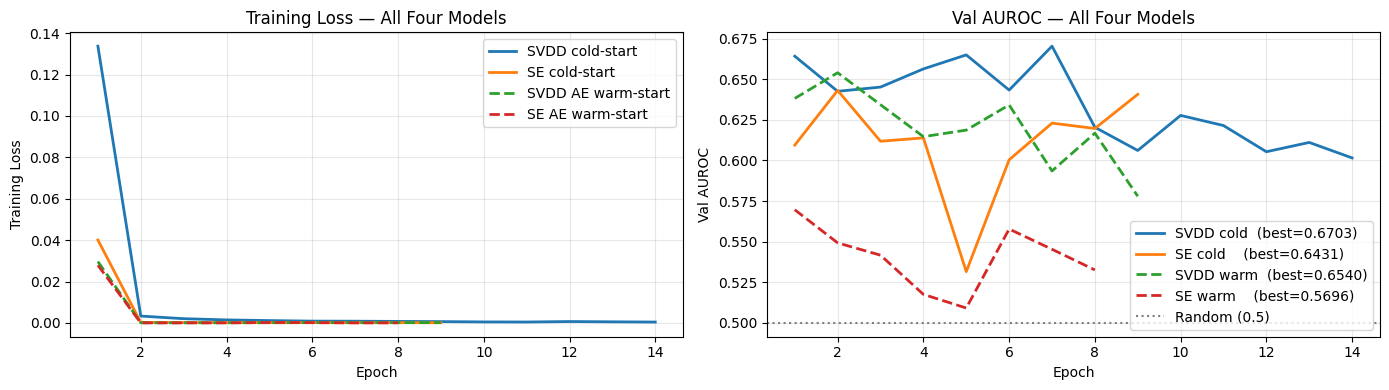


=== 2×2 Results Table (Test AUROC) ===
                             Cold-start   AE Warm-start
DeepSVDD (no SE)                 0.6413          0.6434
DeepSVDDWithSE                   0.6153          0.5781


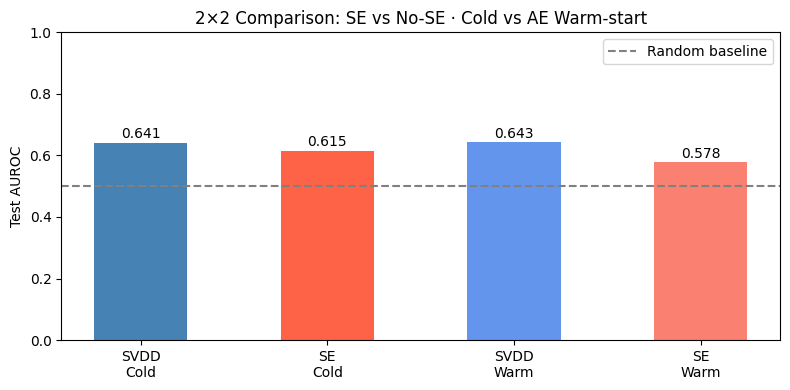

In [ ]:

ckpt_warm = torch.load(os.path.join(CKPT_DIR, "improved_svdd_se_warm_best.pt"),
                        map_location=DEVICE, weights_only=True)
model_se_warm.load_state_dict(ckpt_warm["model_state"])

ckpt_svdd_warm = torch.load(os.path.join(CKPT_DIR, "improved_svdd_warm_best.pt"),
                             map_location=DEVICE, weights_only=True)
model_svdd_warm.load_state_dict(ckpt_svdd_warm["model_state"])


val_scores_se_warm,   _ = eval_scores(model_se_warm,   val_loader, DEVICE)
val_scores_svdd_warm, _ = eval_scores(model_svdd_warm, val_loader, DEVICE)

tau_se_warm,   _ = calibrate_threshold(val_scores_se_warm,   val_labels_cal)
tau_svdd_warm, _ = calibrate_threshold(val_scores_svdd_warm, val_labels_cal)

test_scores_se_warm,   _ = eval_scores(model_se_warm,   test_loader, DEVICE)
test_scores_svdd_warm, _ = eval_scores(model_svdd_warm, test_loader, DEVICE)

metrics_se_warm   = compute_metrics(test_scores_se_warm,   test_labels, tau_se_warm)
metrics_svdd_warm = compute_metrics(test_scores_svdd_warm, test_labels, tau_svdd_warm)

print("DeepSVDDWithSE — AE warm-start")
print_metrics(metrics_se_warm, "DeepSVDDWithSE (AE warm-start)")
print()
print("DeepSVDD — AE warm-start")
print_metrics(metrics_svdd_warm, "DeepSVDD (AE warm-start)")


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_se_w   = range(1, len(train_losses_se_warm)   + 1)
epochs_svdd_w = range(1, len(train_losses_svdd_warm) + 1)

axes[0].plot(epochs_svdd,   train_losses_svdd,      label="SVDD cold-start",    lw=2)
axes[0].plot(epochs_se,     train_losses_se,        label="SE cold-start",      lw=2)
axes[0].plot(epochs_svdd_w, train_losses_svdd_warm, label="SVDD AE warm-start", lw=2, linestyle="--")
axes[0].plot(epochs_se_w,   train_losses_se_warm,   label="SE AE warm-start",   lw=2, linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss — All Four Models")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_svdd,   val_aurocs_svdd,
             label=f"SVDD cold  (best={max(val_aurocs_svdd):.4f})", lw=2)
axes[1].plot(epochs_se,     val_aurocs_se,
             label=f"SE cold    (best={max(val_aurocs_se):.4f})", lw=2)
axes[1].plot(epochs_svdd_w, val_aurocs_svdd_warm,
             label=f"SVDD warm  (best={max(val_aurocs_svdd_warm):.4f})", lw=2, linestyle="--")
axes[1].plot(epochs_se_w,   val_aurocs_se_warm,
             label=f"SE warm    (best={max(val_aurocs_se_warm):.4f})", lw=2, linestyle="--")
axes[1].axhline(0.5, color="grey", linestyle=":", lw=1.5, label="Random (0.5)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val AUROC")
axes[1].set_title("Val AUROC — All Four Models")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "2x2_warmstart_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()


print("\n=== 2×2 Results Table (Test AUROC) ===")
print(f"{'':25s}  {'Cold-start':>12}  {'AE Warm-start':>14}")
print(f"{'DeepSVDD (no SE)':25s}  {metrics_svdd['auroc']:>12.4f}  {metrics_svdd_warm['auroc']:>14.4f}")
print(f"{'DeepSVDDWithSE':25s}  {metrics_se['auroc']:>12.4f}  {metrics_se_warm['auroc']:>14.4f}")


labels_bar = ['SVDD\nCold', 'SE\nCold', 'SVDD\nWarm', 'SE\nWarm']
values     = [metrics_svdd['auroc'], metrics_se['auroc'],
              metrics_svdd_warm['auroc'], metrics_se_warm['auroc']]
colours    = ['steelblue', 'tomato', 'cornflowerblue', 'salmon']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels_bar, values, color=colours, width=0.5)
ax.axhline(0.5, color='grey', linestyle='--', label='Random baseline')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Test AUROC')
ax.set_ylim(0.0, 1.0)
ax.set_title('2×2 Comparison: SE vs No-SE · Cold vs AE Warm-start')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "2x2_bar_chart.png"), dpi=120, bbox_inches="tight")
plt.show()

## Reproducibility: Reload & Re-evaluate

In [ ]:

model_svdd_reload = DeepSVDD(
    freeze_up_to='layer2', hidden_dims=[256], out_dim=OUT_DIM,
    use_bn=False, dropout=0.0, pretrained=False,  # pretrained=False — weights come from checkpoint
).to(DEVICE)

ckpt = torch.load(os.path.join(CKPT_DIR, 'improved_svdd_best.pt'),
                  map_location=DEVICE, weights_only=True)
model_svdd_reload.load_state_dict(ckpt['model_state'])

test_scores_r, test_labels_r = eval_scores(model_svdd_reload, test_loader, DEVICE)
metrics_r = compute_metrics(test_scores_r, test_labels_r, tau_svdd)


print_metrics(metrics_r, 'DeepSVDD (reloaded)')
match = abs(metrics_r['auroc'] - metrics_svdd['auroc']) < 1e-6
print(f'AUROC matches original: {match}')

## Results and Issues
After removing forward normalisation, using bias=False, and freezing encoder BatchNorm layers in eval mode, the plain DeepSVDD model improved to a best validation AUROC of 0.6703 at epoch 7. The centre norm initialised at 2.4356, well above 1.0, confirming that embeddings were no longer artificially constrained to the unit sphere. Training was more stable than before, although the sharp loss drop in the first few epochs still suggested partial collapse. Replacing global average pooling with max pooling slowed convergence and increased the centre norm to 7.4584, but did not improve AUROC. Autoencoder warm-start also failed to help: despite steadily decreasing reconstruction loss, the warm-started SVDD reached only 0.6540 AUROC and collapsed rapidly by epoch 2. Adding SE attention did not resolve the issue, likely because the model collapsed before meaningful channel reweighting could be learned.

### Issues
The main limitation is structural: image-level SVDD compresses the full feature map into a single global embedding, while cracks occupy only a small fraction of the image. With global pooling, these localised anomalies contribute too little to the final representation, so the model struggles to separate crack and non-crack samples reliably. Max pooling does not solve this because by layer4 each spatial location already has a very large receptive field, so the anomaly signal is diluted before pooling.

Overall, the experiments suggest that image-level SVDD is fundamentally mismatched to sparse crack detection. The next steps should focus on stronger anti-collapse regularisation and, more importantly, patch-level SVDD or other spatially-aware formulations that preserve local anomaly structure instead of collapsing the entire image into one vector.